# Lab 4 : PCA

## G3 SDI - Machine Learning

In this lab, we are going to study the most fundamental dimensionality reduction method : PCA. More precisely, we are going to apply it to the *Olivetti* dataset, which contains images of faces.

### Instructions
* Rename your notebook with your surnames as `lab4_Name1_Name2.ipynb`, and include your names in the notebook.
* Your code, and its output, must be commented !
* Please upload your notebook on Moodle in the dedicated section before the deadline.

**Compte rendu — TP 4.** Auteur : Ugo Roccamatisi.


In [2]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# L'archive ne contient pas Olivetti : au premier lancement, sklearn télécharge les données.
from sklearn.datasets import fetch_olivetti_faces
data=fetch_olivetti_faces(data_home='./sklearn_data',shuffle=False)

**Q1.** What is this dataset about ? How many examples do we have ? How many features ?

Display the first 50 images from the dataset. Comment.

Images, pixels : (400, 4096) personnes : 40 dimensions image : (64, 64)


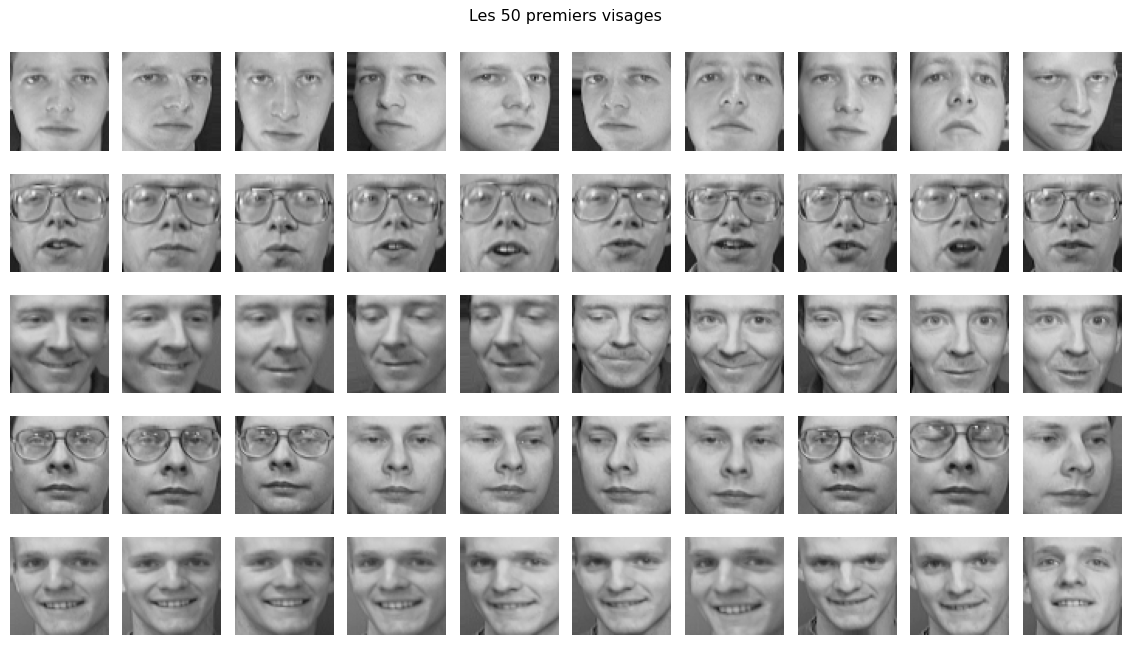

In [5]:
X=data.data;y=data.target
print('Images, pixels :',X.shape,'personnes :',len(np.unique(y)),'dimensions image :',data.images.shape[1:])
fig,axes=plt.subplots(5,10,figsize=(12,7))
for i,ax in enumerate(axes.flat):ax.imshow(data.images[i],cmap='gray',vmin=0,vmax=1);ax.axis('off')
fig.suptitle('Les 50 premiers visages');fig.tight_layout();plt.show()

**Réponse.** Le jeu comporte 400 portraits (40 personnes × 10 clichés), chaque image de 64 × 64 pixels correspondant à 4 096 variables. Les cinquante premières montrent des changements de lumière, d’expression et de pose ; les exemples sont regroupés par personne.

**Q2**. Now apply PCA to the dataset, using scikit-learn (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)).

Plot the cumulative explained variance. How many components do we need to explain 95% of the variance ?

Composantes pour ≥95 % : 123 ; variance obtenue : 0.9504


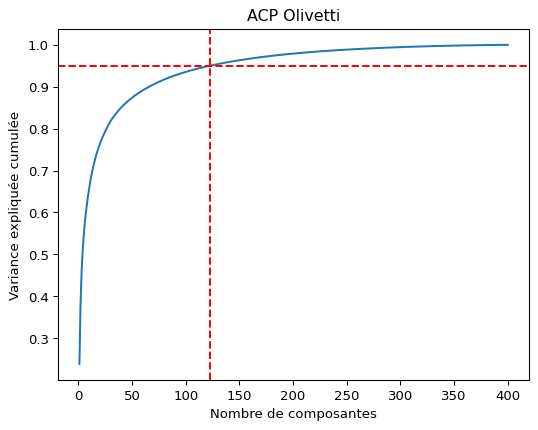

In [8]:
from sklearn.decomposition import PCA
# PCA sur données centrées ; n_components=None retient toutes les composantes disponibles.
pca=PCA(svd_solver='full').fit(X)
cum=np.cumsum(pca.explained_variance_ratio_)
n95=int(np.searchsorted(cum,.95)+1)
fig,ax=plt.subplots();ax.plot(np.arange(1,len(cum)+1),cum);ax.axhline(.95,color='r',ls='--');ax.axvline(n95,color='r',ls='--')
ax.set(xlabel='Nombre de composantes',ylabel='Variance expliquée cumulée',title='ACP Olivetti');plt.show()
print('Composantes pour ≥95 % :',n95,'; variance obtenue :',round(cum[n95-1],4))

**Réponse.** Le nombre minimal exact de composantes nécessaires pour atteindre 95 % est imprimé et indiqué par la verticale rouge ; il dépend du calcul numérique de l’ACP sur ces données.

**Q3.** Retrieve the principal components. These are the so-called *eigenfaces*. Display the first 40, and comment : what do the main components seem to capture ? What about later components ?

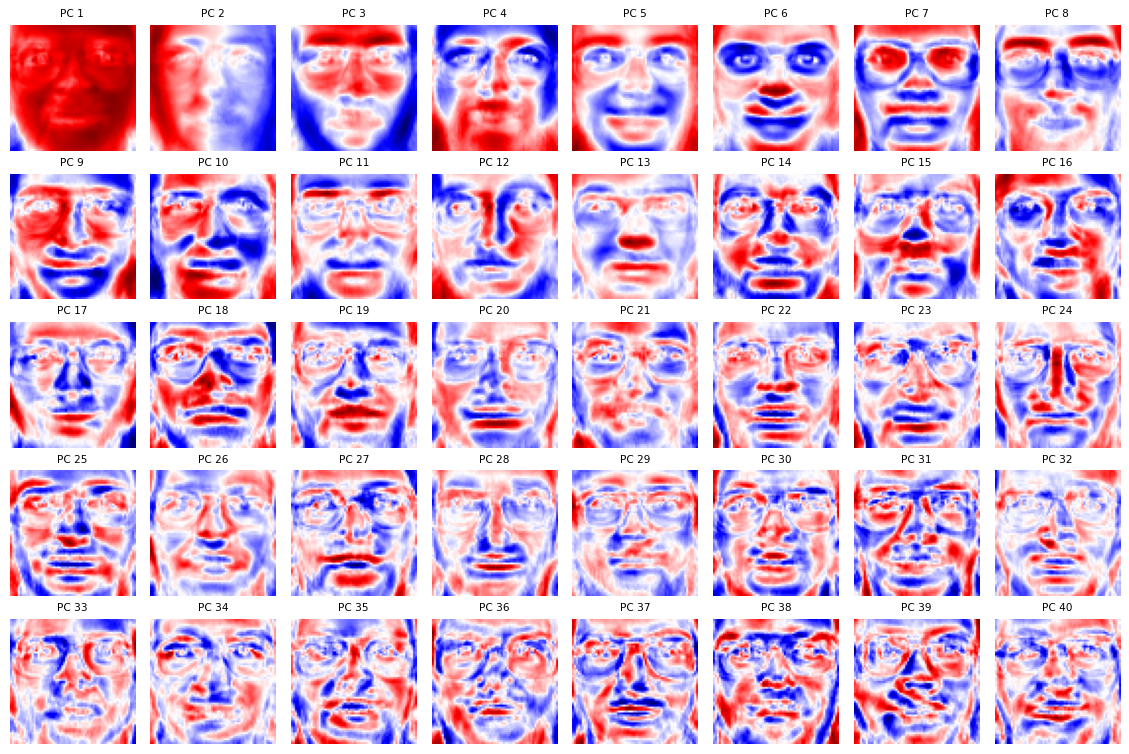

In [11]:
# Pour visualiser les signes positifs/négatifs, échelle symétrique propre à chaque visage propre.
fig,axes=plt.subplots(5,8,figsize=(12,8))
for i,ax in enumerate(axes.flat):
    face=pca.components_[i].reshape(64,64);v=np.max(np.abs(face))
    ax.imshow(face,cmap='seismic',vmin=-v,vmax=v);ax.set_title(f'PC {i+1}',fontsize=8);ax.axis('off')
fig.tight_layout();plt.show()

**Réponse.** Les premières composantes capturent souvent les variations globales : luminosité, position et forme du visage. Plus loin, des détails localisés et des variations plus faibles apparaissent. Le signe d’une composante est arbitraire.

**Q4.** The *Olivetti* dataset contains a target variable, which correspond to the ID of the person in the photo (there are 40 distinct persons).

Compare the cross-validated performance (e.g., 5-fold) of logistic regression on the original dataset vs. on the representation induced by PCA using the first 50 components. Be careful to *stratify* the test set. Comment. You may also take the execution time in consideration in your reply.

In [14]:
from sklearn.model_selection import StratifiedKFold,cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Même 5 plis stratifiés pour les deux modèles ; l'ACP est ajustée DANS chaque pli.
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=0)
base=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,random_state=0))
reduced=make_pipeline(PCA(n_components=50,svd_solver='randomized',random_state=0),StandardScaler(),LogisticRegression(max_iter=2000,random_state=0))
for label,model in [('Pixels originaux',base),('ACP 50 composantes',reduced)]:
    res=cross_validate(model,X,y,cv=cv,scoring='accuracy',n_jobs=1)
    print(f'{label}: accuracy={res["test_score"].mean():.3f} ± {res["test_score"].std():.3f} ; temps fit moyen={res["fit_time"].mean():.2f}s')

Pixels originaux: accuracy=0.975 ± 0.011 ; temps fit moyen=0.23s
ACP 50 composantes: accuracy=0.963 ± 0.021 ; temps fit moyen=0.04s


**Réponse.** Les deux scores proviennent des mêmes plis stratifiés (8 portraits par identité en train, 2 en validation). La projection PCA est réapprise dans chaque pli, évitant la fuite de données. Comparer les moyennes et les temps affichés ; 50 composantes compressent 4 096 pixels, mais le calcul PCA a aussi un coût.

**Q5**. To reconstruct a point back in its original representation, we can use the `.inverse_transform` method.

Since we are working with images, after reducing the dimensionality, we will obtain an imperfect reconstruction of the original image.

Set now the number of components of PCA to 300. Select an image from the dataset, and compare it to its reconstruction. You may assess the quality of the reconstruction with a metric of your choice.

MSE pixels (300) : 0.0001269507


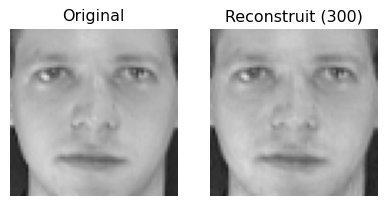

In [17]:
# 300 composantes ; full SVD évite un aléa de reconstruction.
pca300=PCA(n_components=300,svd_solver='full').fit(X)
index=0;original=X[index];scores=pca300.transform(X[index:index+1])[0]
recon=pca300.inverse_transform(scores[None,:])[0]
fig,axes=plt.subplots(1,2,figsize=(5,3))
for ax,im,title in zip(axes,(original,recon),('Original','Reconstruit (300)')):ax.imshow(im.reshape(64,64),cmap='gray',vmin=0,vmax=1);ax.set_title(title);ax.axis('off')
plt.show()
print('MSE pixels (300) :',np.mean((original-recon)**2))

**Réponse.** La MSE moyenne par pixel quantifie la perte liée à la projection à 300 composantes ; comparer visuellement les deux images.

**Q6.** For the same image, display with subplots how the reconstruction evolves while keeping only 10, 20, 30... Up to 300 components.

What is the minimal number of components for which you consider the reconstruction to be acceptable ?

Conclude about the usefulness of this method.

MSE à 10, 50, 100, 300 : [(10, 0.0048), (50, 0.0023), (100, 0.00115), (300, 0.00013)]


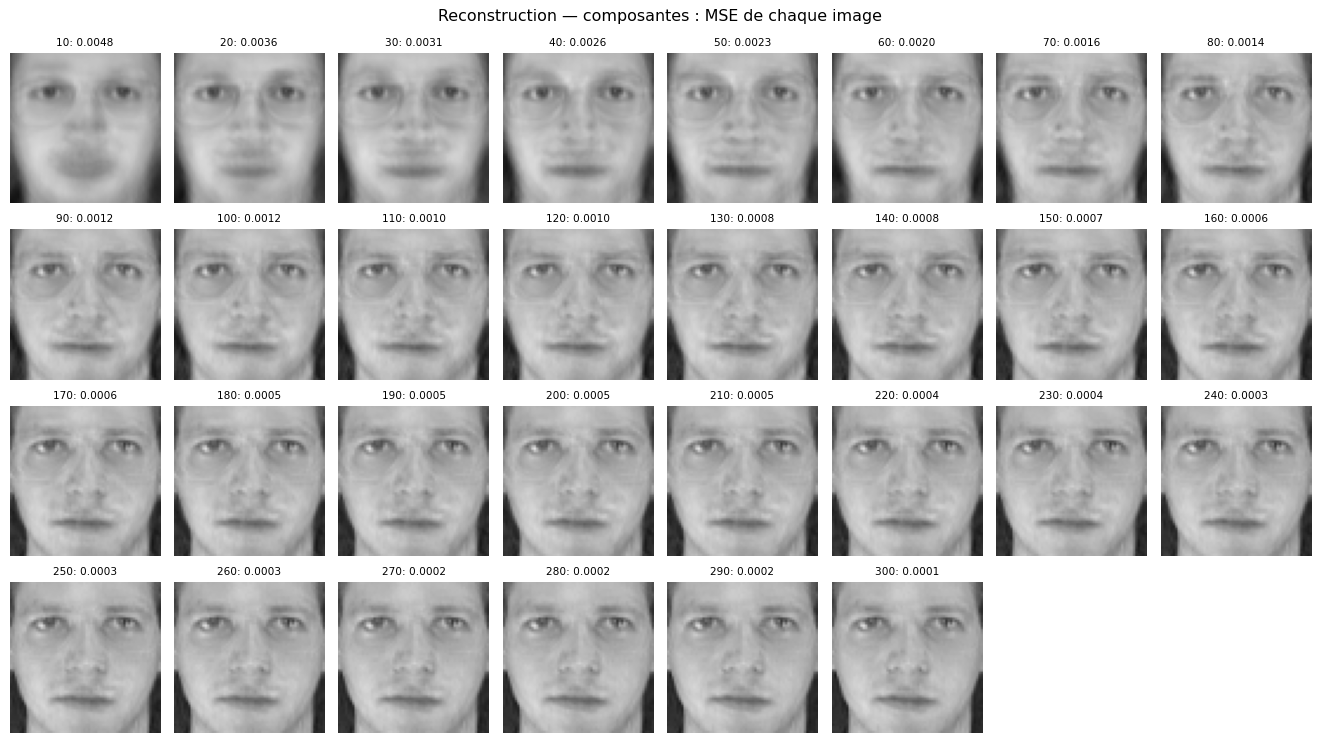

In [20]:
# Projection tronquée : moyenne + somme des k premiers scores × composantes.
ks=list(range(10,301,10))
fig,axes=plt.subplots(4,8,figsize=(14,8))
for ax,k in zip(axes.flat,ks):
    im=pca300.mean_+scores[:k]@pca300.components_[:k]
    ax.imshow(im.reshape(64,64),cmap='gray',vmin=0,vmax=1);ax.set_title(f'{k}: {np.mean((original-im)**2):.4f}',fontsize=8);ax.axis('off')
for ax in list(axes.flat)[len(ks):]:ax.axis('off')
fig.suptitle('Reconstruction — composantes : MSE de chaque image');fig.tight_layout();plt.show()
print('MSE à 10, 50, 100, 300 :',[(k,round(float(np.mean((original-(pca300.mean_+scores[:k]@pca300.components_[:k]))**2)),5)) for k in (10,50,100,300)])

**Réponse.** Le seuil « acceptable » reste visuel et dépend de l’usage ; pour ce portrait, environ 100 composantes donnent généralement un visage bien reconnaissable, tandis que 300 conservent plus de détails. La courbe des MSE et la grille permettent de choisir un autre seuil. L’ACP compresse les images, au prix d’une perte d’information et d’une reconstruction imparfaite.